# Logistic Regression: Logistic Loss

## Goals
See why squared error cost is a bad fit for logistic regression, and build the logistic loss function that replaces it.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
#sigmoid fucntion

def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return np.clip(g, 1e-10, 1 - 1e-10)

## Squared Error Recap
For linear regression, the cost function was:
J(w,b) = (1/2m) * sum((f(x) - y)^2)
This gave a smooth, bowl-shaped cost surface (convex) - gradient descent could always find the bottom.

### Squared Error With Sigmoid
Let's try the same squared error cost, but now f(x) uses sigmoid: f(x) = sigmoid(w*x + b). We'll compute cost across a range of w values (b fixed) and see if it's still smooth.

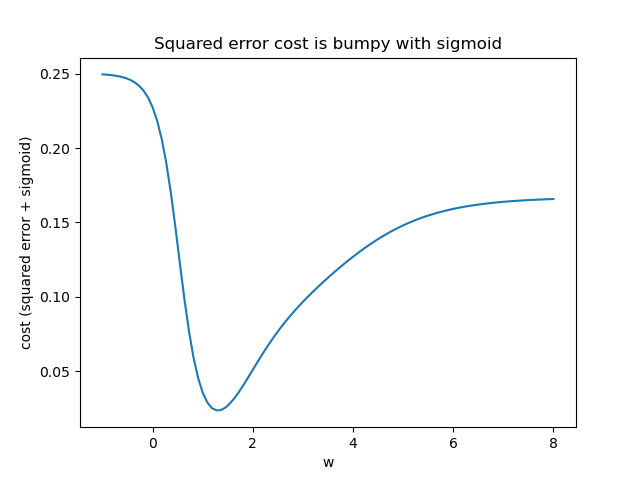

In [6]:
x_train = np.array([0., 1, 2, 3, 4, 5])
y_train = np.array([0, 0, 0, 1, 1, 1])

def compute_cost_squared_sigmoid(x,y,w,b):
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = sigmoid(w*x[i]+b)
        cost+= (f_wb_i-y[i])**2
    return cost/(2*m)

w_range = np.linspace(-1, 8, 100)
b_fixed = -3
# For EACH of the 100 w values, run the ENTIRE function above once.
# Each run of the function internally loops through all 6 examples.
# Total sigmoid calculations = 100 w-values x 6 examples each = 600
costs = [compute_cost_squared_sigmoid(x_train, y_train, w, b_fixed) for w in w_range] #calling for each w value
plt.figure()
plt.plot(w_range, costs)
plt.xlabel('w')
plt.ylabel('cost (squared error + sigmoid)')
plt.title('Squared error cost is bumpy with sigmoid')
plt.savefig("squared_error_sigmoid.png")
plt.close()

from IPython.display import Image
Image("squared_error_sigmoid.png")

## Logistic Loss Function

Definitions used in this course:
- Loss: how wrong a SINGLE example's prediction is
- Cost: the average of losses across ALL examples

Logistic loss is defined as two separate cases:
loss = -log(f(x))       if y = 1
loss = -log(1 - f(x))   if y = 0

In [7]:
def loss_y1(f):
    return -np.log(f)
def loss_y0(f):
    return -np.log(1-f)

Let's plot both loss curves - what happens as the prediction f(x) ranges from near 0 to near 1, for each true label case.

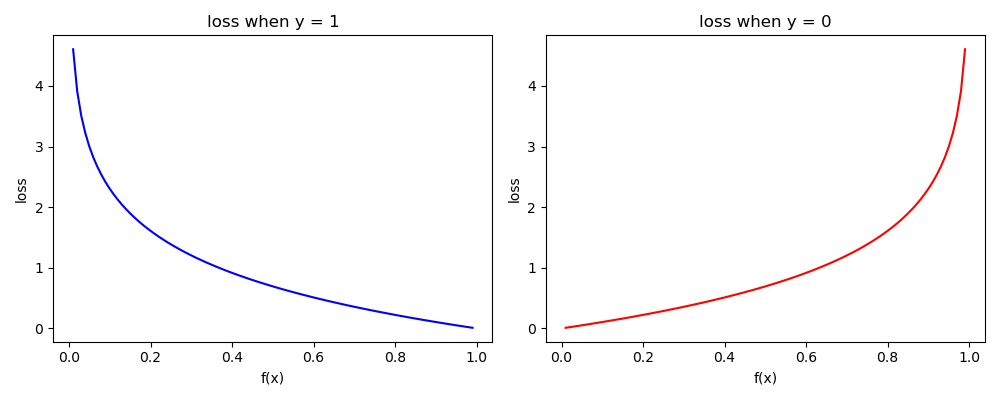

In [11]:
f = np.linspace(0.01, 0.99, 100)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(f, loss_y1(f), c='b')
ax[0].set_title("loss when y = 1")
ax[0].set_xlabel("f(x)")
ax[0].set_ylabel("loss")

ax[1].plot(f, loss_y0(f), c='r')
ax[1].set_title("loss when y = 0")
ax[1].set_xlabel("f(x)")
ax[1].set_ylabel("loss")

plt.tight_layout()
plt.savefig("logistic_loss_curves.png")
plt.close()

from IPython.display import Image
Image("logistic_loss_curves.png")

The two-case loss function can be rewritten as one single formula:

loss = -y*log(f) - (1-y)*log(1-f)

When y=1, the second term vanishes (multiplied by 0), leaving -log(f).
When y=0, the first term vanishes, leaving -log(1-f).

In [14]:
def logistic_loss(f,y):
    return -y*np.log(f) - (1-y)*np.log(1-f)


### Logistic Cost Function
Cost is the average of the logistic loss across all training examples.

In [15]:
def compute_cost_logistic(x, y, w, b):
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        f_wb_i = sigmoid(w * x[i] + b)
        cost += logistic_loss(f_wb_i, y[i])
    return cost / m

Now let's plot cost vs w (b fixed) using logistic loss, and compare to the bumpy squared-error version from earlier.

C:\Users\Abdullah Javed\AppData\Local\Temp\ipykernel_5916\1253622042.py:2: RuntimeWarning: divide by zero encountered in log
  return -y*np.log(f) - (1-y)*np.log(1-f)
C:\Users\Abdullah Javed\AppData\Local\Temp\ipykernel_5916\1253622042.py:2: RuntimeWarning: invalid value encountered in scalar multiply
  return -y*np.log(f) - (1-y)*np.log(1-f)


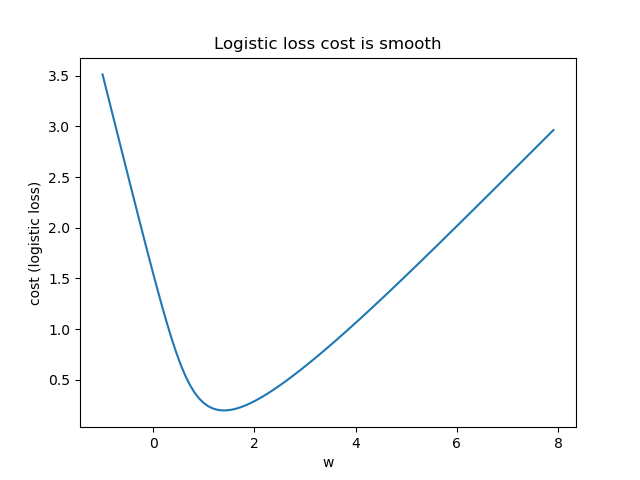

In [16]:
w_range = np.linspace(-1, 8, 100)
b_fixed = -3
costs_logistic = [compute_cost_logistic(x_train, y_train, w, b_fixed) for w in w_range]

plt.figure()
plt.plot(w_range, costs_logistic)
plt.xlabel('w')
plt.ylabel('cost (logistic loss)')
plt.title('Logistic loss cost is smooth')
plt.savefig("logistic_cost_smooth.png")
plt.close()

from IPython.display import Image
Image("logistic_cost_smooth.png")